# Hafta 2: Seq Nesnesi, Merkezi Dogma ve Genetik Kod

**Biyoenformatiğe Giriş (Python & Biopython)**

**Bu haftanın hedefleri**
1. `Seq` ve `MutableSeq` nesnelerinin yöntemlerini kullanmak (dilimleme, sayma, arama, birleştirme).
2. Transkripsiyon, translasyon ve altı okuma çerçevesini Biopython ile uygulamak.
3. Genetik kod tablolarını (standart, bakteriyel, mitokondriyal) karşılaştırmak.
4. GC içeriği, erime sıcaklığı (Tm) ve molekül ağırlığı gibi temel sayısal büyüklükleri hesaplamak.

> **Kullanım:** Colab'da *Çalışma zamanı → Tümünü çalıştır* ile tüm hücreleri sırayla çalıştırabilirsiniz. Alıştırmaların çözümleri notebook'un sonundadır; önce kendiniz deneyin.

In [1]:
# Colab'da gerekli kütüphaneleri kur (yalnızca ilk çalıştırmada birkaç saniye sürer)
!pip -q install biopython 
import Bio
print('Biopython sürümü:', Bio.__version__)

Biopython sürümü: 1.88


## 1. `Seq` nesnesi: Python dizgisi gibi, ama biyolojik yöntemlerle
`Seq` nesnesi Python `str` gibi dilimlenebilir, birleştirilebilir, `len()` ile ölçülebilir.
Farkı: `complement()`, `translate()` gibi biyolojik yöntemleri vardır ve **değiştirilemez (immutable)**dir.

In [2]:
from Bio.Seq import Seq, MutableSeq

gen = Seq("ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG")
print("Uzunluk      :", len(gen))
print("Dilim [3:12] :", gen[3:12])
print("Her 3. baz   :", gen[::3])
print("Ters çevrilmiş:", gen[::-1], "(dikkat: bu ters tamamlayıcı DEĞİL)")
print("'ATG' sayısı :", gen.count("ATG"), "| ilk konum:", gen.find("ATG"))
print("Örtüşmeli 'AA' sayısı:", gen.count_overlap("AA"), "| örtüşmesiz:", gen.count("AA"))
print("Birleştirme  :", gen[:6] + Seq("NNNN") + gen[-6:])
print("str'ye dönüşüm:", str(gen)[:10], type(str(gen)))

Uzunluk      : 39
Dilim [3:12] : GCCATTGTA
Her 3. baz   : AGAGAGCTAGGCT
Ters çevrilmiş: GATAGCCCGTGGGAAAGTCGCCGGGTAATGTTACCGGTA (dikkat: bu ters tamamlayıcı DEĞİL)
'ATG' sayısı : 2 | ilk konum: 0
Örtüşmeli 'AA' sayısı: 3 | örtüşmesiz: 2
Birleştirme  : ATGGCCNNNNCGATAG
str'ye dönüşüm: ATGGCCATTG <class 'str'>


In [3]:
# Değiştirilebilir dizi: nokta mutasyonu yapmak için MutableSeq
m = MutableSeq(str(gen))
m[5] = "T"             # C -> T (6. baz): GCC -> GCT, ikisi de Alanin kodlar = SESSİZ mutasyon
print("Orijinal:", gen[:12])
print("Mutant  :", m[:12])
print("Mutant protein:", Seq(m).translate(), " | Orijinal:", gen.translate())
m[4] = "A"             # GCT -> GAT : Alanin -> Aspartat = ANLAMLI (missense) mutasyon
print("İkinci mutasyon sonrası:", Seq(m).translate())

Orijinal: ATGGCCATTGTA
Mutant  : ATGGCTATTGTA
Mutant protein: MAIVMGR*KGAR*  | Orijinal: MAIVMGR*KGAR*
İkinci mutasyon sonrası: MDIVMGR*KGAR*


## 2. Tamamlayıcı iplik ve transkripsiyon

```
5'-ATGGCC...-3'   kodlayan (sense) iplik
3'-TACCGG...-5'   kalıp (template/antisense) iplik
5'-AUGGCC...-3'   mRNA  (= kodlayan iplikte T→U)
```
Biyolojide RNA polimeraz **kalıp ipliği** okur; ama sonuç kodlayan ipliğin T→U halidir.
Bu yüzden Biopython `transcribe()` yöntemi sadece T→U değişimi yapar.

In [4]:
kodlayan = Seq("ATGGCCATTGTAATGGGCCGCTGA")
kalip = kodlayan.reverse_complement()
print("Kodlayan iplik   :", kodlayan)
print("Kalıp (5'->3')   :", kalip)
mrna = kodlayan.transcribe()
print("mRNA             :", mrna)
print("Kalıptan mRNA    :", kalip.reverse_complement().transcribe())
print("Geri transkripsiyon:", mrna.back_transcribe())

Kodlayan iplik   : ATGGCCATTGTAATGGGCCGCTGA
Kalıp (5'->3')   : TCAGCGGCCCATTACAATGGCCAT
mRNA             : AUGGCCAUUGUAAUGGGCCGCUGA
Kalıptan mRNA    : AUGGCCAUUGUAAUGGGCCGCUGA
Geri transkripsiyon: ATGGCCATTGTAATGGGCCGCTGA


## 3. Translasyon ve genetik kod

In [5]:
from Bio.Data import CodonTable

standart = CodonTable.unambiguous_dna_by_id[1]
print(standart)

Table 1 Standard, SGC0

  |  T      |  C      |  A      |  G      |
--+---------+---------+---------+---------+--
T | TTT F   | TCT S   | TAT Y   | TGT C   | T
T | TTC F   | TCC S   | TAC Y   | TGC C   | C
T | TTA L   | TCA S   | TAA Stop| TGA Stop| A
T | TTG L(s)| TCG S   | TAG Stop| TGG W   | G
--+---------+---------+---------+---------+--
C | CTT L   | CCT P   | CAT H   | CGT R   | T
C | CTC L   | CCC P   | CAC H   | CGC R   | C
C | CTA L   | CCA P   | CAA Q   | CGA R   | A
C | CTG L(s)| CCG P   | CAG Q   | CGG R   | G
--+---------+---------+---------+---------+--
A | ATT I   | ACT T   | AAT N   | AGT S   | T
A | ATC I   | ACC T   | AAC N   | AGC S   | C
A | ATA I   | ACA T   | AAA K   | AGA R   | A
A | ATG M(s)| ACG T   | AAG K   | AGG R   | G
--+---------+---------+---------+---------+--
G | GTT V   | GCT A   | GAT D   | GGT G   | T
G | GTC V   | GCC A   | GAC D   | GGC G   | C
G | GTA V   | GCA A   | GAA E   | GGA G   | A
G | GTG V   | GCG A   | GAG E   | GGG G   | G
--+---------

In [6]:
print("Başlangıç kodonları (standart):", standart.start_codons)
print("Dur kodonları (standart)       :", standart.stop_codons)

mito = CodonTable.unambiguous_dna_by_id[2]   # omurgalı mitokondriyal kod
farklar = [(k, standart.forward_table.get(k, "*"), mito.forward_table.get(k, "*"))
           for k in sorted(set(standart.forward_table) | set(standart.stop_codons))
           if standart.forward_table.get(k, "*") != mito.forward_table.get(k, "*")]
print("\nStandart ve mitokondriyal kod arasındaki farklar:")
for k, s1, s2 in farklar:
    print(f"  {k}: standart={s1}  mitokondriyal={s2}")

Başlangıç kodonları (standart): ['TTG', 'CTG', 'ATG']
Dur kodonları (standart)       : ['TAA', 'TAG', 'TGA']

Standart ve mitokondriyal kod arasındaki farklar:
  AGA: standart=R  mitokondriyal=*
  AGG: standart=R  mitokondriyal=*
  ATA: standart=I  mitokondriyal=M
  TGA: standart=*  mitokondriyal=W


In [7]:
dizi = Seq("ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG")
print("translate()           :", dizi.translate())
print("to_stop=True          :", dizi.translate(to_stop=True))
print("stop_symbol='@'       :", dizi.translate(stop_symbol="@"))
print("table=2 (mitokondri)  :", dizi.translate(table=2))

cds = Seq("ATGGCCATTGTAATGGGCCGCTGA")
print("cds=True (tam gen)    :", cds.translate(cds=True))
try:
    Seq("ATGGCCATTG").translate(cds=True)
except Exception as hata:
    print("Hatalı CDS denetimi   :", hata)

translate()           : MAIVMGR*KGAR*
to_stop=True          : MAIVMGR
stop_symbol='@'       : MAIVMGR@KGAR@
table=2 (mitokondri)  : MAIVMGRWKGAR*
cds=True (tam gen)    : MAIVMGR
Hatalı CDS denetimi   : Sequence length 10 is not a multiple of three


### Kendi çeviri fonksiyonumuz (algoritmayı anlamak için)

In [8]:
def cevir(dizi, tablo=standart):
    protein = []
    for i in range(0, len(dizi) - len(dizi) % 3, 3):
        kodon = str(dizi[i:i+3])
        if kodon in tablo.stop_codons:
            protein.append("*")
        else:
            protein.append(tablo.forward_table.get(kodon, "X"))
    return "".join(protein)

print(cevir(dizi))
assert cevir(dizi) == str(dizi.translate())
print("Biopython ile aynı ✔")

MAIVMGR*KGAR*
Biopython ile aynı ✔


## 4. Altı okuma çerçevesi
Bir DNA parçası 3 ileri + 3 ters (ters tamamlayıcı üzerinde) olmak üzere 6 farklı şekilde okunabilir.

| Çerçeve | Başlangıç | İplik |
|---|---|---|
| +1, +2, +3 | 0, 1, 2 | verilen iplik |
| −1, −2, −3 | 0, 1, 2 | ters tamamlayıcı |

In [9]:
def alti_cerceve(dizi):
    sonuc = {}
    for iplik, d in [("+", dizi), ("-", dizi.reverse_complement())]:
        for kaydirma in range(3):
            parca = d[kaydirma:]
            parca = parca[: len(parca) - len(parca) % 3]   # 3'ün katına kırp
            sonuc[f"{iplik}{kaydirma+1}"] = parca.translate()
    return sonuc

for cerceve, prot in alti_cerceve(dizi).items():
    print(f"{cerceve}: {prot}")

+1: MAIVMGR*KGAR*
+2: WPL*WAAERVPD
+3: GHCNGPLKGCPI
-1: LSGTLSAAHYNGH
-2: YRAPFQRPITMA
-3: IGHPFSGPLQWP


## 5. Sayısal büyüklükler

### 5.1 GC içeriği
$GC\% = \dfrac{n_G + n_C}{n_A+n_C+n_G+n_T}\times 100$

### 5.2 Erime sıcaklığı (Tm) — primer tasarımında kullanılır
* **Wallace kuralı** (≤ 14 nt primerler): $T_m = 2(n_A+n_T) + 4(n_G+n_C)$ °C
* **GC formülü** (daha uzun diziler): $T_m = 64.9 + 41\cdot\dfrac{n_G+n_C-16.4}{N}$ °C
* **En yakın komşu (nearest-neighbor)** modeli: termodinamik parametrelerle en doğru sonuç (`Tm_NN`).

### Sayısal örnek — `5'-AGCTTAGCGATCGT-3'` (14 nt) primeri
| Büyüklük | Hesap | Sonuç |
|---|---|---|
| Baz sayıları | A=3, C=3, G=4, T=4 | N = 14 |
| GC% | (4+3)/14 | %50 |
| Wallace Tm | 2·(3+4) + 4·(4+3) | 42 °C |
| GC formülü | 64.9 + 41·(7−16.4)/14 | ≈ 37.4 °C |

In [10]:
from Bio.SeqUtils import gc_fraction, molecular_weight
from Bio.SeqUtils import MeltingTemp as mt

primer = Seq("AGCTTAGCGATCGT")
print("Baz sayıları:", {b: primer.count(b) for b in "ACGT"})
print(f"GC oranı      : {gc_fraction(primer):.3f}")
print(f"Wallace Tm    : {mt.Tm_Wallace(primer):.1f} °C")
print(f"GC formülü Tm : {mt.Tm_GC(primer, Na=50, valueset=7):.1f} °C  (tuz düzeltmeli Biopython sürümü)")
print(f"Elle GC formülü: {64.9 + 41*(7 - 16.4)/14:.1f} °C")
print(f"En yakın komşu: {mt.Tm_NN(primer):.1f} °C")

Baz sayıları: {'A': 3, 'C': 3, 'G': 4, 'T': 4}
GC oranı      : 0.500
Wallace Tm    : 42.0 °C
GC formülü Tm : 37.5 °C  (tuz düzeltmeli Biopython sürümü)
Elle GC formülü: 37.4 °C
En yakın komşu: 41.4 °C


> **Not:** Biopython'un `Tm_GC` fonksiyonu tuz (Na⁺) düzeltmesi içeren farklı bir parametre setini kullanabildiği için
elle bulduğumuz basit formül sonucundan birkaç derece farklı olabilir. Pratikte `Tm_NN` tercih edilir.

### 5.3 Molekül ağırlığı
Tek iplikli DNA için yaklaşık: $MW \approx n_A\cdot 331.2 + n_C\cdot 307.2 + n_G\cdot 347.2 + n_T\cdot 322.2 - 61.96$ (Da)
(nükleotit monofosfat kütleleri; 5' ucunda fosfat yok). Biopython `molecular_weight` doğrudan hesaplar:

In [11]:
print(f"ssDNA MW  : {molecular_weight(primer, 'DNA'):.1f} Da")
print(f"dsDNA MW  : {molecular_weight(primer, 'DNA', double_stranded=True):.1f} Da")
print(f"Protein MW: {molecular_weight(Seq('MAIVMGR'), 'protein'):.1f} Da")

ssDNA MW  : 4358.8 Da
dsDNA MW  : 8686.5 Da
Protein MW: 777.0 Da


## 6. Uygulama: GC içeriği boyunca kayan pencere
Genomlarda GC oranı bölgeden bölgeye değişir. **Kayan pencere (sliding window)** yöntemi,
her pencere için oranı hesaplayıp bir profil çizer.

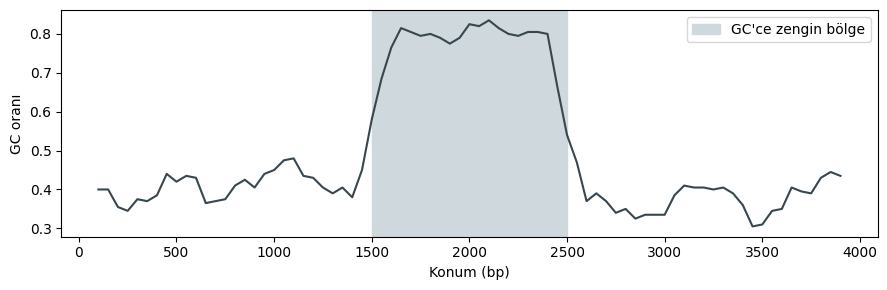

In [12]:
import random
import matplotlib.pyplot as plt

random.seed(1)
# Ortası GC'ce zengin sentetik bir dizi oluşturalım
parca1 = "".join(random.choices("ACGT", weights=[3, 2, 2, 3], k=1500))
parca2 = "".join(random.choices("ACGT", weights=[1, 4, 4, 1], k=1000))
parca3 = "".join(random.choices("ACGT", weights=[3, 2, 2, 3], k=1500))
uzun = Seq(parca1 + parca2 + parca3)

def kayan_gc(dizi, pencere=200, adim=50):
    x, y = [], []
    for i in range(0, len(dizi) - pencere + 1, adim):
        x.append(i + pencere // 2)
        y.append(gc_fraction(dizi[i:i + pencere]))
    return x, y

x, y = kayan_gc(uzun)
plt.figure(figsize=(9, 3))
plt.plot(x, y, color="#37474f")
plt.axvspan(1500, 2500, color="#cfd8dc", label="GC'ce zengin bölge")
plt.xlabel("Konum (bp)"); plt.ylabel("GC oranı"); plt.legend(); plt.tight_layout(); plt.show()

## 7. Mutasyonların etkisi: eş anlamlı ve eş anlamlı olmayan değişimler
Bir kodonun 3. bazındaki değişim çoğu zaman amino asidi değiştirmez (**sessiz/sinonim** mutasyon).
Tüm tek-baz değişimlerini sayarak her kodon konumunun ne kadar "hassas" olduğunu ölçelim.

In [13]:
import collections

sayac = collections.Counter()
toplam = collections.Counter()
for kodon, aa in standart.forward_table.items():
    for konum in range(3):
        for yeni in "ACGT":
            if yeni == kodon[konum]:
                continue
            mutant = kodon[:konum] + yeni + kodon[konum+1:]
            aa2 = standart.forward_table.get(mutant, "*")
            toplam[konum] += 1
            if aa2 == aa:
                sayac[konum] += 1

for konum in range(3):
    print(f"Kodonun {konum+1}. bazı: sinonim değişim oranı = {sayac[konum]/toplam[konum]:.2f}")

Kodonun 1. bazı: sinonim değişim oranı = 0.04
Kodonun 2. bazı: sinonim değişim oranı = 0.00
Kodonun 3. bazı: sinonim değişim oranı = 0.69


## 8. Alıştırmalar
1. `ATGAAACCCGGGTTTTAA` dizisinin mRNA'sını, proteinini ve ters tamamlayıcısını bulun. Elle çözün, sonra kodla kontrol edin.
2. `ATGTGGTGA` dizisini standart kod ve mitokondriyal kod (tablo 2) ile çevirin. Neden farklı?
3. 20 nt'lik `GCGTACGTTAGCATGCATGC` primerinin Wallace, GC ve NN yöntemleriyle Tm değerlerini karşılaştırın.
   Hangi yöntem bu uzunluk için uygun değildir?
4. Rastgele 999 bazlık bir dizi üretin (`random.seed(3)`), altı okuma çerçevesinin her birinde kaç dur kodonu (`*`) olduğunu sayın.
   Beklenen değer nedir? *(İpucu: 64 kodonun 3'ü dur kodonudur.)*

---
## Çözümler

In [14]:
# 1
d = Seq("ATGAAACCCGGGTTTTAA")
print("1) mRNA:", d.transcribe(), "| protein:", d.translate(), "| ters tamamlayıcı:", d.reverse_complement())

# 2
d = Seq("ATGTGGTGA")
print("2) standart:", d.translate(), "| mitokondriyal:", d.translate(table=2),
      "-> TGA mitokondride Triptofan (W) kodlar")

# 3
p = Seq("GCGTACGTTAGCATGCATGC")
print(f"3) Wallace={mt.Tm_Wallace(p):.1f}  GC={mt.Tm_GC(p):.1f}  NN={mt.Tm_NN(p):.1f} °C "
      "-> Wallace kuralı 14 nt'den uzun primerler için uygun değildir")

# 4
random.seed(3)
r = Seq("".join(random.choices("ACGT", k=999)))
for c, prot in alti_cerceve(r).items():
    print(f"4) {c}: {prot.count('*')} dur kodonu", end="  ")
print(f"\n   Beklenen ≈ 333 kodon × 3/64 ≈ {333*3/64:.1f}")

1) mRNA: AUGAAACCCGGGUUUUAA | protein: MKPGF* | ters tamamlayıcı: TTAAAACCCGGGTTTCAT
2) standart: MW* | mitokondriyal: MWW -> TGA mitokondride Triptofan (W) kodlar
3) Wallace=62.0  GC=52.5  NN=55.1 °C -> Wallace kuralı 14 nt'den uzun primerler için uygun değildir
4) +1: 13 dur kodonu  4) +2: 12 dur kodonu  4) +3: 16 dur kodonu  4) -1: 15 dur kodonu  4) -2: 12 dur kodonu  4) -3: 19 dur kodonu  
   Beklenen ≈ 333 kodon × 3/64 ≈ 15.6
